
# Finetune CTUnet Ore/Talc Segmentation With Active-Learning Masks

Finetune the source ore/background segmentation model using the previous source binary dataset plus reviewed masks saved by the active-learning UI.

The active-learning class-index masks are converted to three trainable target classes:

- source binary/background pixels and reviewed background remain `background`;
- sulfide-like classes, oxide ore, normal ore, and hard ore become `ore`;
- reviewed talc becomes `talc`; reviewed talc pixels have target class `2`;
- only `ignore` pixels receive zero loss weight.

The model architecture is CTUnet, implemented by `create_ct_unet`, with `LEARNING_RATE = 1e-4`. The notebook saves a multiclass checkpoint with `class_names = ('background', 'ore', 'talc')` so inference can expose a talc class output.


In [2]:
from pathlib import Path
import json
import sys
import time

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

try:
    import torch
    import torch.nn.functional as F
except ModuleNotFoundError:
    torch = None
    F = None

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / 'src').exists():
            PROJECT_ROOT = parent.resolve()
            break
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from ore_detection.models.ct_unet import create_ct_unet
from ore_detection.training.active_learning_binary import (
    balanced_class_weights_from_counts,
    TARGET_BACKGROUND_INDEX,
    TARGET_CLASS_NAMES,
    TARGET_ORE_INDEX,
    TARGET_TALC_INDEX,
    list_active_learning_binary_samples,
    load_active_learning_binary_sample,
    load_active_learning_binary_tensors,
)
from ore_detection.training.source_binary_const import (
    SOURCE_BINARY_TRAIN_RGB_MEAN,
    SOURCE_BINARY_TRAIN_RGB_STD,
    SOURCE_BINARY_TRAIN_STATS_IMAGE_COUNT,
)
from ore_detection.training.source_binary_gpu_training import (
    augment_source_binary_batch,
    list_downsampled_source_binary_samples,
    load_cached_binary_tensors,
    normalize_binary_images,
)

DOWNSAMPLED_ROOT = PROJECT_ROOT / 'data_work' / 'source_binary_downsampled'
ACTIVE_LEARNING_ROOT = PROJECT_ROOT / 'data_work' / 'active_learning_masks'
BASE_CHECKPOINT = PROJECT_ROOT / 'models' / 'source_binary_segmentation' / '001' / 'best.pt'
MODEL_FAMILY = 'source_binary_segmentation_ct_unet'
MODEL_SERIAL = '001'
MODELS_ROOT = PROJECT_ROOT / 'models' / MODEL_FAMILY / MODEL_SERIAL

RUN_TRAINING = False
RUN_PREVIEW = True
TRAIN_ON_SOURCE_TEST = False   # set True only for a final production fit after evaluation is no longer needed
LOAD_BASE_CHECKPOINT = True
STRICT_CHECKPOINT_LOAD = False
ACTIVE_SAMPLE_LIMIT = None     # None means all active-learning reviewed samples
PREVIEW_LIMIT = 3

IMAGE_SIZE = 512
BATCH_SIZE = 16
EPOCHS = 80
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
EVAL_EVERY_N_EPOCHS = 1
BEST_CHECKPOINT_MIN_EPOCH = 5
DEVICE = 'cuda' if torch is not None and torch.cuda.is_available() else 'cpu'
USE_GPU_CACHE = True
USE_GPU_AUGMENTATION = True
PIN_MEMORY = True
AUG_SCALE_RANGE = (0.5, 2.0)
AUG_BRIGHTNESS_RANGE = (0.6, 1.4)
AUG_CONTRAST_RANGE = (0.6, 1.4)
TARGET_CLASS_COUNT = len(TARGET_CLASS_NAMES)

CTUNET_MODEL_KWARGS = {
    'out_channels': TARGET_CLASS_COUNT,
    'base_channels': 16,
    'num_heads': 4,
    'transformer_layers': 2,
    'token_grid_size': 16,
}

print('project', PROJECT_ROOT)
print('active learning root', ACTIVE_LEARNING_ROOT)
print('base checkpoint', BASE_CHECKPOINT)
print('output model root', MODELS_ROOT)
print('device', DEVICE)
print('learning rate', LEARNING_RATE)
print('target class names', TARGET_CLASS_NAMES)
print('model kwargs', CTUNET_MODEL_KWARGS)


project C:\Users\Cape\PycharmProjects\ore_detection
active learning root C:\Users\Cape\PycharmProjects\ore_detection\data_work\active_learning_masks
base checkpoint C:\Users\Cape\PycharmProjects\ore_detection\models\source_binary_segmentation\001\best.pt
output model root C:\Users\Cape\PycharmProjects\ore_detection\models\source_binary_segmentation_ct_unet\001
device cuda
learning rate 0.0001
target class names ('background', 'ore', 'talc')
model kwargs {'out_channels': 3, 'base_channels': 16, 'num_heads': 4, 'transformer_layers': 2, 'token_grid_size': 16}


## Load Previous and Active-Learning Samples

The previous source dataset is loaded from existing downsampled binary tensors. Active-learning samples are loaded from `data_work/active_learning_masks`; panorama reviews contribute reviewed patch tensors, while direct edited masks contribute their full edited mask.

In [3]:
source_train_samples = list_downsampled_source_binary_samples(DOWNSAMPLED_ROOT, split='train')
source_test_samples = list_downsampled_source_binary_samples(DOWNSAMPLED_ROOT, split='test')
source_training_samples = source_train_samples + (source_test_samples if TRAIN_ON_SOURCE_TEST else [])

active_samples_all = list_active_learning_binary_samples(ACTIVE_LEARNING_ROOT)
active_samples = active_samples_all if ACTIVE_SAMPLE_LIMIT is None else active_samples_all[:ACTIVE_SAMPLE_LIMIT]

print(f'source train samples: {len(source_train_samples)}')
print(f'source test samples: {len(source_test_samples)}')
print(f'source samples used for finetune train: {len(source_training_samples)}')
print(f'active-learning ore/talc samples available: {len(active_samples_all)}')
print(f'active-learning ore/talc samples used: {len(active_samples)}')
print(f'train RGB mean: {SOURCE_BINARY_TRAIN_RGB_MEAN}')
print(f'train RGB std: {SOURCE_BINARY_TRAIN_RGB_STD}')
print(f'train stats image count: {SOURCE_BINARY_TRAIN_STATS_IMAGE_COUNT}')

if active_samples:
    first = active_samples[0]
    print('first active sample:', first.sample_id, first.source_image_path, first.crop_box)


source train samples: 134
source test samples: 46
source samples used for finetune train: 134
active-learning ore/talc samples available: 95
active-learning ore/talc samples used: 95
train RGB mean: (0.4691853836690349, 0.4398698336579204, 0.4024980066350099)
train RGB std: (0.25512571009385043, 0.2335228905839328, 0.2100037541533096)
train stats image count: 134
first active sample: 0467565b2ef3_patch_00001 C:\Users\Cape\PycharmProjects\ore_detection\datasets\baseline\Part 1\Talc contained\DSCN4715.JPG (0, 0, 512, 512)



## Preview Active-Learning Ore/Talc Targets

Preview reviewed active-learning samples before training. The target panel shows class indices: `0=background`, `1=ore`, `2=talc`. The loss-weight panel shows pixels that contribute to the multiclass loss; only `ignore` is black in the loss-weight panel.


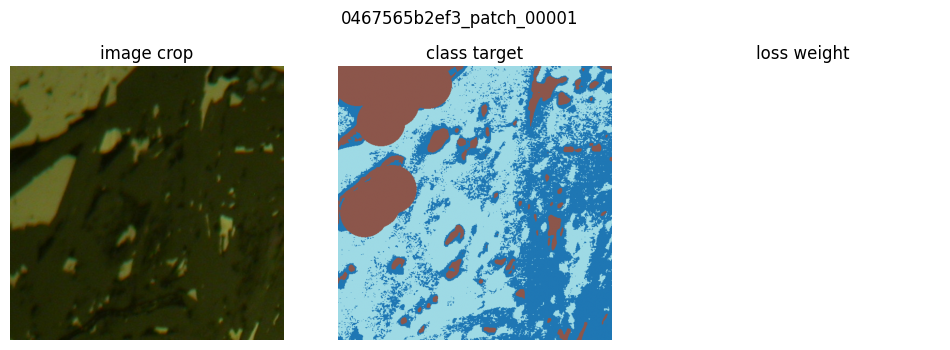

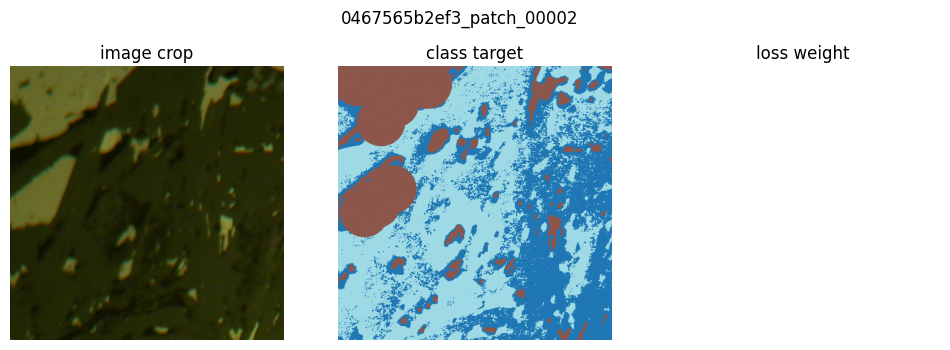

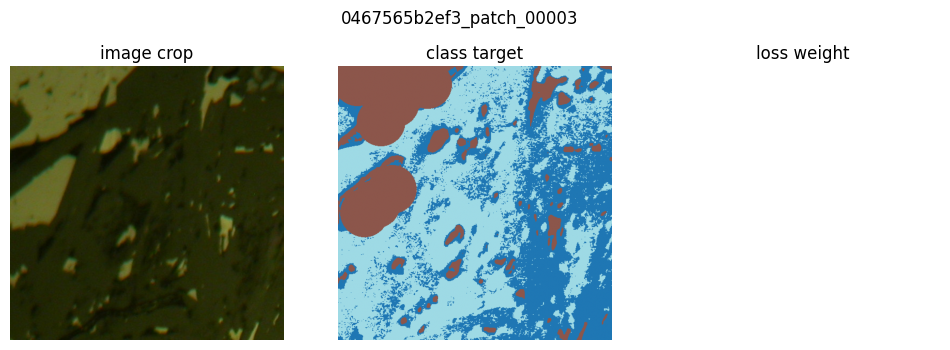

In [4]:

if RUN_PREVIEW and torch is not None and active_samples:
    for sample in active_samples[:PREVIEW_LIMIT]:
        row = load_active_learning_binary_sample(sample, output_size=IMAGE_SIZE)
        image = row['image'].permute(1, 2, 0).numpy()
        mask = row['mask'].numpy()
        weight = row['weight'].numpy()
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(image)
        axes[0].set_title('image crop')
        axes[1].imshow(mask, cmap='tab20', vmin=0, vmax=TARGET_CLASS_COUNT - 1)
        axes[1].set_title('class target')
        axes[2].imshow(weight, cmap='gray', vmin=0, vmax=1)
        axes[2].set_title('loss weight')
        fig.suptitle(sample.sample_id)
        for ax in axes:
            ax.axis('off')
        plt.show()
elif RUN_PREVIEW and torch is None:
    print('PyTorch is not installed; skipping active-learning preview.')
elif RUN_PREVIEW:
    print('No active-learning samples found to preview.')



## Weighted Cache Helpers

Source binary masks are treated as `background`/`ore` targets with unit loss weight. Active-learning samples use the same target tensor but can contain `talc=2`; only `ignore` pixels have zero weight. The combined cache keeps images, class-index masks, weights, and sample references together.


In [5]:
def cache_with_unit_weights(cache):
    cache = dict(cache)
    cache['weight'] = torch.ones_like(cache['mask'], dtype=torch.uint8, device=cache['mask'].device)
    return cache


def resize_cache_spatial(cache, *, output_size):
    cache = dict(cache)
    target_size = (int(output_size), int(output_size))
    if tuple(cache['image'].shape[-2:]) == target_size:
        return cache
    image_dtype = cache['image'].dtype
    mask_dtype = cache['mask'].dtype
    weight_dtype = cache['weight'].dtype
    cache['image'] = F.interpolate(
        cache['image'].float(),
        size=target_size,
        mode='bilinear',
        align_corners=False,
    ).to(dtype=image_dtype)
    cache['mask'] = F.interpolate(
        cache['mask'].float().unsqueeze(1),
        size=target_size,
        mode='nearest',
    ).squeeze(1).to(dtype=mask_dtype)
    cache['weight'] = (F.interpolate(
        cache['weight'].float().unsqueeze(1),
        size=target_size,
        mode='nearest',
    ).squeeze(1) > 0.5).to(dtype=weight_dtype)
    return cache


def concatenate_caches(*caches):
    present = [cache for cache in caches if cache is not None]
    if not present:
        raise ValueError('cannot concatenate empty caches')
    return {
        'image': torch.cat([cache['image'] for cache in present], dim=0),
        'mask': torch.cat([cache['mask'] for cache in present], dim=0),
        'weight': torch.cat([cache['weight'] for cache in present], dim=0),
        'samples': sum((list(cache.get('samples', [])) for cache in present), []),
    }


def iter_weighted_class_batches(cached, *, batch_size, shuffle, generator=None):
    images = cached['image']
    masks = cached['mask']
    weights = cached['weight']
    sample_count = int(images.shape[0])
    if shuffle:
        order = torch.randperm(sample_count, device=images.device, generator=generator)
    else:
        order = torch.arange(sample_count, device=images.device)
    samples = cached.get('samples', [])
    for start in range(0, sample_count, batch_size):
        index = order[start:start + batch_size]
        yield {
            'image': images.index_select(0, index).float(),
            'mask': masks.index_select(0, index).long(),
            'weight': weights.index_select(0, index).float(),
            'samples': [samples[int(i.detach().cpu())] for i in index] if samples else [],
        }


def class_pixel_count_vector(cache):
    values = cache['mask'].detach().cpu()
    weights = cache['weight'].detach().cpu() > 0
    return [int(((values == class_index) & weights).sum().item()) for class_index in range(TARGET_CLASS_COUNT)]


def class_pixel_counts(cache):
    counts = class_pixel_count_vector(cache)
    return {class_name: counts[class_index] for class_index, class_name in enumerate(TARGET_CLASS_NAMES)}


def class_weights_from_cache(cache, *, device):
    counts = class_pixel_count_vector(cache)
    weights = balanced_class_weights_from_counts(counts, min_weight=1.0, max_weight=8.0)
    return torch.tensor(weights, dtype=torch.float32, device=device)


## Weighted Multiclass Loss and Metrics

The cross-entropy and Dice terms are weighted per pixel and per class. Pixels with zero weight do not contribute to loss or IoU. Class weights are computed from the train cache as `sqrt(max_class_frequency / class_frequency_i)` and clamped to `[1, 8]`, so talc contributes materially even when it is rare compared with background.


In [6]:
def weighted_mean(values, weights, eps=1e-6):
    return (values * weights).sum() / weights.sum().clamp_min(eps)


def _class_weights_for_logits(class_weights, logits):
    if class_weights is None:
        return None
    return class_weights.to(device=logits.device, dtype=logits.dtype)


def multiclass_weighted_dice_loss_from_logits(logits, target, weights, *, class_weights=None, eps=1e-6):
    probs = F.softmax(logits, dim=1)
    target_one_hot = F.one_hot(target.long().clamp(0, TARGET_CLASS_COUNT - 1), num_classes=TARGET_CLASS_COUNT)
    target_one_hot = target_one_hot.permute(0, 3, 1, 2).to(dtype=probs.dtype)
    weights_ch = weights.float().unsqueeze(1)
    intersection = (probs * target_one_hot * weights_ch).sum(dim=(2, 3))
    denominator = ((probs + target_one_hot) * weights_ch).sum(dim=(2, 3))
    dice = (2 * intersection + eps) / (denominator + eps)
    resolved_class_weights = _class_weights_for_logits(class_weights, logits)
    if resolved_class_weights is None:
        return 1 - dice.mean()
    weighted_dice = (dice * resolved_class_weights.view(1, -1)).sum(dim=1) / resolved_class_weights.sum().clamp_min(eps)
    return 1 - weighted_dice.mean()


def class_iou_from_logits(logits, target, weights, class_index, eps=1e-7):
    pred = logits.argmax(dim=1)
    valid = weights > 0.5
    pred_class = pred == int(class_index)
    target_class = target == int(class_index)
    intersection = (pred_class & target_class & valid).sum(dim=(1, 2)).float()
    union = ((pred_class | target_class) & valid).sum(dim=(1, 2)).float()
    return ((intersection + eps) / (union + eps)).mean()


def compute_segmentation_loss(model, image, target, weight, *, class_weights=None):
    logits = model(image)
    resolved_class_weights = _class_weights_for_logits(class_weights, logits)
    ce_pixels = F.cross_entropy(logits, target.long(), weight=resolved_class_weights, reduction='none')
    ce_loss = weighted_mean(ce_pixels, weight)
    dice_loss = multiclass_weighted_dice_loss_from_logits(logits, target, weight, class_weights=resolved_class_weights)
    loss = ce_loss + dice_loss
    class_ious = {
        f'{class_name}_iou': class_iou_from_logits(logits.detach(), target, weight, class_index)
        for class_index, class_name in enumerate(TARGET_CLASS_NAMES)
    }
    mean_iou = sum(class_ious.values()) / max(1, len(class_ious))
    metrics = {
        'loss': float(loss.detach().cpu()),
        'cross_entropy_loss': float(ce_loss.detach().cpu()),
        'dice_loss': float(dice_loss.detach().cpu()),
        'mean_iou': float(mean_iou.detach().cpu()),
    }
    metrics.update({key: float(value.detach().cpu()) for key, value in class_ious.items()})
    return loss, metrics


def prediction_diagnostics(model, cached, device, *, class_weights=None):
    model.eval()
    pred_counts = [0 for _ in TARGET_CLASS_NAMES]
    label_counts = [0 for _ in TARGET_CLASS_NAMES]
    true_positive = [0 for _ in TARGET_CLASS_NAMES]
    false_positive = [0 for _ in TARGET_CLASS_NAMES]
    false_negative = [0 for _ in TARGET_CLASS_NAMES]
    with torch.no_grad():
        for batch in iter_weighted_class_batches(cached, batch_size=BATCH_SIZE, shuffle=False):
            image = batch['image'].to(device, non_blocking=True)
            target = batch['mask'].to(device, non_blocking=True)
            weight = batch['weight'].to(device, non_blocking=True)
            image = normalize_binary_images(image, mean=SOURCE_BINARY_TRAIN_RGB_MEAN, std=SOURCE_BINARY_TRAIN_RGB_STD)
            logits = model(image)
            pred = logits.argmax(dim=1)
            valid = weight > 0.5
            for class_index in range(TARGET_CLASS_COUNT):
                pred_class = pred == class_index
                target_class = target == class_index
                pred_counts[class_index] += int((pred_class & valid).sum().detach().cpu())
                label_counts[class_index] += int((target_class & valid).sum().detach().cpu())
                true_positive[class_index] += int((pred_class & target_class & valid).sum().detach().cpu())
                false_positive[class_index] += int((pred_class & ~target_class & valid).sum().detach().cpu())
                false_negative[class_index] += int((~pred_class & target_class & valid).sum().detach().cpu())
    diagnostics = {}
    for class_index, class_name in enumerate(TARGET_CLASS_NAMES):
        tp = true_positive[class_index]
        fp = false_positive[class_index]
        fn = false_negative[class_index]
        diagnostics[f'{class_name}_pred_pixels'] = pred_counts[class_index]
        diagnostics[f'{class_name}_label_pixels'] = label_counts[class_index]
        diagnostics[f'{class_name}_precision'] = tp / max(1, tp + fp)
        diagnostics[f'{class_name}_recall'] = tp / max(1, tp + fn)
        diagnostics[f'{class_name}_iou'] = tp / max(1, tp + fp + fn)
    return diagnostics


def selection_score_from_metrics(active_diagnostics, test_metrics):
    if active_diagnostics is None or test_metrics is None:
        return None
    return (
        0.4 * active_diagnostics['talc_iou']
        + 0.4 * active_diagnostics['ore_iou']
        + 0.2 * test_metrics['ore_iou']
    )


def mean_metrics(rows):
    if not rows:
        return {
            'loss': None,
            'cross_entropy_loss': None,
            'dice_loss': None,
            'mean_iou': None,
            'background_iou': None,
            'ore_iou': None,
            'talc_iou': None,
        }
    return {key: sum(row[key] for row in rows) / len(rows) for key in rows[0]}


## Train and Evaluate Functions

In [7]:
def train_one_epoch(model, cached, optimizer, device, *, class_weights):
    model.train()
    rows = []
    for batch in iter_weighted_class_batches(cached, batch_size=BATCH_SIZE, shuffle=True):
        image = batch['image'].to(device, non_blocking=True)
        mask = batch['mask'].to(device, non_blocking=True)
        weight = batch['weight'].to(device, non_blocking=True)
        if USE_GPU_AUGMENTATION:
            image, mask_ch, weight_ch = augment_source_binary_batch(
                image,
                mask.float().unsqueeze(1),
                weights=weight.float().unsqueeze(1),
                output_size=IMAGE_SIZE,
                binarize_masks=False,
                scale_range=AUG_SCALE_RANGE,
                brightness_range=AUG_BRIGHTNESS_RANGE,
                contrast_range=AUG_CONTRAST_RANGE,
            )
            mask = mask_ch.squeeze(1).long()
            weight = weight_ch.squeeze(1)
        image = normalize_binary_images(image, mean=SOURCE_BINARY_TRAIN_RGB_MEAN, std=SOURCE_BINARY_TRAIN_RGB_STD)

        optimizer.zero_grad(set_to_none=True)
        loss, metrics = compute_segmentation_loss(model, image, mask, weight, class_weights=class_weights)
        loss.backward()
        optimizer.step()
        rows.append(metrics)
    return mean_metrics(rows)


def evaluate(model, cached, device, *, class_weights):
    model.eval()
    rows = []
    with torch.no_grad():
        for batch in iter_weighted_class_batches(cached, batch_size=BATCH_SIZE, shuffle=False):
            image = batch['image'].to(device, non_blocking=True)
            mask = batch['mask'].to(device, non_blocking=True)
            weight = batch['weight'].to(device, non_blocking=True)
            image = normalize_binary_images(image, mean=SOURCE_BINARY_TRAIN_RGB_MEAN, std=SOURCE_BINARY_TRAIN_RGB_STD)
            _, metrics = compute_segmentation_loss(model, image, mask, weight, class_weights=class_weights)
            rows.append(metrics)
    return mean_metrics(rows)


## CTUnet Checkpoint Helpers

`load_matching_checkpoint_weights` supports warm-starting from the existing trained binary checkpoint. If the checkpoint architecture differs, only tensors with matching names and shapes are loaded; the notebook reports how many were reused.

In [8]:
def create_model():
    return create_ct_unet(**CTUNET_MODEL_KWARGS)


def load_matching_checkpoint_weights(model, checkpoint_path, *, device):
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.exists():
        return {'loaded': 0, 'skipped': 0, 'reason': 'checkpoint does not exist'}
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    except TypeError:
        checkpoint = torch.load(checkpoint_path, map_location=device)
    source_state = checkpoint.get('model', checkpoint) if isinstance(checkpoint, dict) else checkpoint
    target_state = model.state_dict()
    matched = {
        key: value
        for key, value in source_state.items()
        if key in target_state and tuple(value.shape) == tuple(target_state[key].shape)
    }
    if STRICT_CHECKPOINT_LOAD:
        model.load_state_dict(source_state)
        return {'loaded': len(source_state), 'skipped': 0, 'strict': True}
    target_state.update(matched)
    model.load_state_dict(target_state)
    return {
        'loaded': len(matched),
        'skipped': len(source_state) - len(matched),
        'strict': False,
        'source_notebook': checkpoint.get('notebook') if isinstance(checkpoint, dict) else None,
        'source_architecture': checkpoint.get('architecture', 'simple_unet') if isinstance(checkpoint, dict) else 'state_dict',
    }


def finite_or_none(value):
    if value is None:
        return None
    if value == float('inf') or value == float('-inf'):
        return None
    return float(value)


def checkpoint_payload(
    model,
    optimizer,
    *,
    epoch,
    train_metrics,
    test_metrics,
    active_diagnostics,
    selection_score,
    best_test_loss,
    best_selection_score,
    class_weights,
    warm_start_report,
):
    return {
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'epoch': epoch,
        'train_metrics': train_metrics,
        'test_metrics': test_metrics,
        'active_diagnostics': active_diagnostics,
        'selection_score': finite_or_none(selection_score),
        'best_test_loss': finite_or_none(best_test_loss),
        'best_selection_score': finite_or_none(best_selection_score),
        'architecture': 'ct_unet',
        'model_kwargs': dict(CTUNET_MODEL_KWARGS),
        'class_names': tuple(TARGET_CLASS_NAMES),
        'background_index': TARGET_BACKGROUND_INDEX,
        'image_size': IMAGE_SIZE,
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'class_weights': [float(value) for value in class_weights.detach().cpu().tolist()],
        'normalization': {
            'mean': SOURCE_BINARY_TRAIN_RGB_MEAN,
            'std': SOURCE_BINARY_TRAIN_RGB_STD,
            'train_stats_image_count': SOURCE_BINARY_TRAIN_STATS_IMAGE_COUNT,
        },
        'augmentation': {
            'use_gpu_augmentation': USE_GPU_AUGMENTATION,
            'scale_range': AUG_SCALE_RANGE,
            'brightness_range': AUG_BRIGHTNESS_RANGE,
            'contrast_range': AUG_CONTRAST_RANGE,
            'weighted_loss': True,
            'class_weighted_cross_entropy': True,
            'class_weighted_dice': True,
            'talc_pixels_ignored': False,
            'ignore_pixels_ignored': True,
            'talc_class_index': TARGET_TALC_INDEX,
        },
        'selection': {
            'metric': 'selection_score',
            'formula': '0.4 * active_talc_iou + 0.4 * active_ore_iou + 0.2 * source_ore_iou',
            'requires_active_talc_pred_pixels_gt_zero': True,
            'warning_after_epoch': BEST_CHECKPOINT_MIN_EPOCH,
        },
        'dataset': {
            'source_train_samples': len(source_training_samples),
            'source_test_samples': len(source_test_samples),
            'active_learning_samples': len(active_samples),
            'target_class_names': tuple(TARGET_CLASS_NAMES),
            'train_on_source_test': TRAIN_ON_SOURCE_TEST,
            'active_learning_root': str(ACTIVE_LEARNING_ROOT),
        },
        'warm_start': {
            'enabled': LOAD_BASE_CHECKPOINT,
            'checkpoint': str(BASE_CHECKPOINT),
            'report': warm_start_report,
        },
        'notebook': '08_finetune_binary_segmentation_ctunet_active_learning.ipynb',
    }


def safe_torch_save(payload, target_path, *, retries=8, delay_seconds=0.5):
    target_path = Path(target_path)
    target_path.parent.mkdir(parents=True, exist_ok=True)
    last_error = None
    for attempt in range(1, retries + 1):
        temp_path = target_path.with_name(f'.{target_path.stem}.{time.time_ns()}.tmp')
        try:
            torch.save(payload, temp_path)
            temp_path.replace(target_path)
            return target_path
        except (OSError, RuntimeError) as exc:
            last_error = exc
            try:
                if temp_path.exists():
                    temp_path.unlink()
            except OSError:
                pass
            if attempt < retries:
                time.sleep(delay_seconds * attempt)
    epoch = payload.get('epoch', 'unknown') if isinstance(payload, dict) else 'unknown'
    fallback_path = target_path.with_name(
        f'{target_path.stem}_epoch_{epoch}_{time.strftime("%Y%m%d_%H%M%S")}{target_path.suffix}'
    )
    torch.save(payload, fallback_path)
    print(f'warning: could not update {target_path}; saved fallback {fallback_path}; error={last_error!r}')
    return fallback_path


def plot_training_history(history):
    metric_specs = [
        ('loss', 'total loss'),
        ('cross_entropy_loss', 'weighted cross entropy loss'),
        ('dice_loss', 'weighted multiclass dice loss'),
        ('mean_iou', 'mean target IoU'),
        ('ore_iou', 'ore IoU'),
        ('talc_iou', 'talc IoU'),
    ]
    epochs = [row['epoch'] for row in history]
    fig, axes = plt.subplots(len(metric_specs), 1, figsize=(10, 15), sharex=True, constrained_layout=True)
    for axis, (metric_name, title) in zip(axes, metric_specs):
        train_values = [row['train'][metric_name] for row in history]
        test_values = [row['test'][metric_name] if row['test'] is not None else None for row in history]
        axis.plot(epochs, train_values, marker='o', label='train')
        axis.plot(epochs, test_values, marker='o', label='test')
        axis.set_title(title)
        axis.set_ylabel(metric_name)
        axis.grid(True, alpha=0.3)
        axis.legend()
    axes[-1].set_xlabel('epoch')
    plt.show()
    return fig



## Finetune

This cell is disabled by default. Enable `RUN_TRAINING` after reviewing the active-learning targets and confirming the output serial folder. The cell refuses to train if the combined train cache has zero talc pixels, because this checkpoint is expected to learn a real talc output class.


train cache image: (229, 3, 512, 512) torch.float16
train cache mask: (229, 512, 512) torch.uint8
train cache weight: (229, 512, 512) torch.uint8
train target class pixels: {'background': 34702801, 'ore': 23699205, 'talc': 1628970}
active target class pixels: {'background': 21717809, 'ore': 1556901, 'talc': 1628970}
test target class pixels: {'background': 4130144, 'ore': 7928480, 'talc': 0}
class weights: {'background': 1.0, 'ore': 1.2100836038589478, 'talc': 4.615573883056641}
warm start: {'loaded': 2, 'skipped': 24, 'strict': False, 'source_notebook': '01_train_source_binary_segmentation.ipynb', 'source_architecture': 'simple_unet'}


c:\Program Files\Python313\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


CTUnet ore/talc finetune:   0%|          | 0/80 [00:00<?, ?it/s]

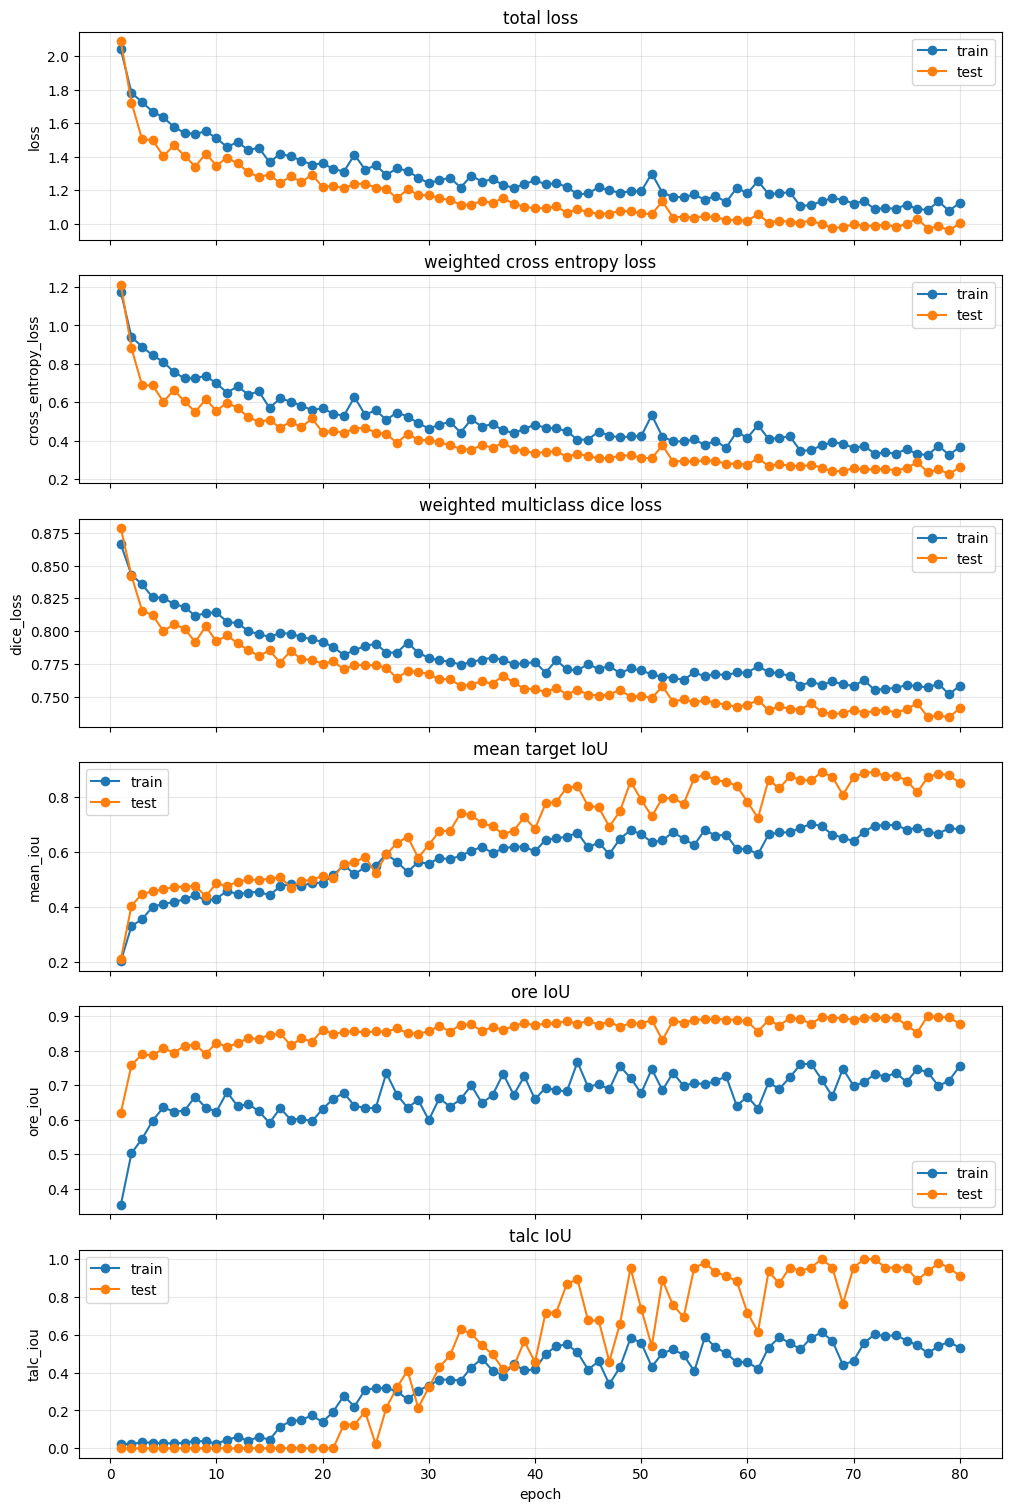

In [9]:
if True:
    if torch is None:
        raise RuntimeError('PyTorch is required for CTUnet finetuning.')
    if not source_training_samples:
        raise RuntimeError('No previous source binary train samples found. Prepare data_work/source_binary_downsampled first.')
    if not source_test_samples:
        raise RuntimeError('No source binary test samples found for evaluation.')
    if not active_samples:
        raise RuntimeError('No active-learning samples found. Save reviewed masks from the UI first.')
    if SOURCE_BINARY_TRAIN_STATS_IMAGE_COUNT == 0:
        raise RuntimeError('Train RGB stats are empty. Prepare the source binary downsampled dataset first.')

    device = torch.device(DEVICE if DEVICE == 'cuda' and torch.cuda.is_available() else 'cpu')
    if device.type == 'cuda':
        torch.backends.cudnn.benchmark = True
    cache_device = device if USE_GPU_CACHE and device.type == 'cuda' else torch.device('cpu')
    use_pin_memory = PIN_MEMORY and cache_device.type == 'cpu' and device.type == 'cuda'

    source_train_cache = resize_cache_spatial(
        cache_with_unit_weights(
            load_cached_binary_tensors(source_training_samples, device=cache_device, pin_memory=use_pin_memory)
        ),
        output_size=IMAGE_SIZE,
    )
    active_train_cache = load_active_learning_binary_tensors(
        active_samples,
        device=cache_device,
        output_size=IMAGE_SIZE,
        pin_memory=use_pin_memory,
    )
    train_cache = concatenate_caches(source_train_cache, active_train_cache)
    test_cache = resize_cache_spatial(
        cache_with_unit_weights(
            load_cached_binary_tensors(source_test_samples, device=cache_device, pin_memory=use_pin_memory)
        ),
        output_size=IMAGE_SIZE,
    )
    print('train cache image:', tuple(train_cache['image'].shape), train_cache['image'].dtype)
    print('train cache mask:', tuple(train_cache['mask'].shape), train_cache['mask'].dtype)
    print('train cache weight:', tuple(train_cache['weight'].shape), train_cache['weight'].dtype)
    train_counts = class_pixel_counts(train_cache)
    active_counts = class_pixel_counts(active_train_cache)
    test_counts = class_pixel_counts(test_cache)
    print('train target class pixels:', train_counts)
    print('active target class pixels:', active_counts)
    print('test target class pixels:', test_counts)
    if train_counts.get('talc', 0) == 0:
        raise RuntimeError('No talc pixels found in the train cache. Add reviewed talc masks before training this three-class checkpoint.')

    class_weights = class_weights_from_cache(train_cache, device=device)
    print('class weights:', {name: float(class_weights[index].detach().cpu()) for index, name in enumerate(TARGET_CLASS_NAMES)})

    model = create_model().to(device)
    warm_start_report = {'enabled': False}
    if LOAD_BASE_CHECKPOINT:
        warm_start_report = load_matching_checkpoint_weights(model, BASE_CHECKPOINT, device=device)
        print('warm start:', warm_start_report)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    MODELS_ROOT.mkdir(parents=True, exist_ok=True)

    history = []
    best_test_loss = float('inf')
    best_selection_score = float('-inf')
    with tqdm(range(1, EPOCHS + 1), desc='CTUnet ore/talc finetune') as pbar:
        for epoch in pbar:
            train_metrics = train_one_epoch(model, train_cache, optimizer, device, class_weights=class_weights)
            test_metrics = None
            active_diagnostics = None
            selection_score = None
            if epoch % EVAL_EVERY_N_EPOCHS == 0 or epoch == EPOCHS:
                test_metrics = evaluate(model, test_cache, device, class_weights=class_weights)
                active_diagnostics = prediction_diagnostics(model, active_train_cache, device, class_weights=class_weights)
                selection_score = selection_score_from_metrics(active_diagnostics, test_metrics)
                if test_metrics is not None and test_metrics['loss'] < best_test_loss:
                    best_test_loss = test_metrics['loss']
                if epoch >= BEST_CHECKPOINT_MIN_EPOCH and active_diagnostics['talc_pred_pixels'] == 0:
                    print(
                        f"warning: epoch {epoch} predicted zero talc pixels on active train cache; "
                        "best.pt will not be updated until talc_pred_pixels > 0."
                    )

            row = {
                'epoch': epoch,
                'train': train_metrics,
                'test': test_metrics,
                'active_diagnostics': active_diagnostics,
                'selection_score': selection_score,
            }
            history.append(row)
            postfix = {
                'train_loss': f"{train_metrics['loss']:.4f}",
                'train_miou': f"{train_metrics['mean_iou']:.4f}",
                'train_talc_iou': f"{train_metrics['talc_iou']:.4f}",
            }
            if test_metrics is not None:
                postfix['test_loss'] = f"{test_metrics['loss']:.4f}"
                postfix['test_miou'] = f"{test_metrics['mean_iou']:.4f}"
            if active_diagnostics is not None:
                postfix['active_talc_pred'] = str(active_diagnostics['talc_pred_pixels'])
            if selection_score is not None:
                postfix['selection'] = f"{selection_score:.4f}"
            pbar.set_postfix(postfix)

            payload = checkpoint_payload(
                model,
                optimizer,
                epoch=epoch,
                train_metrics=train_metrics,
                test_metrics=test_metrics,
                active_diagnostics=active_diagnostics,
                selection_score=selection_score,
                best_test_loss=best_test_loss,
                best_selection_score=best_selection_score,
                class_weights=class_weights,
                warm_start_report=warm_start_report,
            )
            safe_torch_save(payload, MODELS_ROOT / 'last.pt')
            talc_prediction_ok = active_diagnostics is not None and active_diagnostics['talc_pred_pixels'] > 0
            if selection_score is not None and talc_prediction_ok and selection_score > best_selection_score:
                best_selection_score = selection_score
                payload = checkpoint_payload(
                    model,
                    optimizer,
                    epoch=epoch,
                    train_metrics=train_metrics,
                    test_metrics=test_metrics,
                    active_diagnostics=active_diagnostics,
                    selection_score=selection_score,
                    best_test_loss=best_test_loss,
                    best_selection_score=best_selection_score,
                    class_weights=class_weights,
                    warm_start_report=warm_start_report,
                )
                safe_torch_save(payload, MODELS_ROOT / 'best.pt')
            (MODELS_ROOT / 'history.json').write_text(json.dumps(history, indent=2), encoding='utf-8')
    plot_training_history(history)
else:
    print('RUN_TRAINING is False; set it to True after previewing active-learning masks.')
